# Assignment 3 - Part 2: Denoising Autoencoder for Tiny-ImageNet-10

## Objective
Train an autoencoder to denoise corrupted images (Gaussian or Salt-Pepper noise) and reconstruct the original clean images using MSE loss.

**Deliverable**: Show a "Reconstruction Trio" - Original Clean, Noisy Input, Denoised Output

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [3]:
# Noise corruption functions

def add_gaussian_noise(image, noise_std=0.1):
    """Add Gaussian noise to image"""
    noise = torch.randn_like(image) * noise_std
    noisy_image = torch.clamp(image + noise, 0, 1)
    return noisy_image

def add_salt_pepper_noise(image, noise_prob=0.1):
    """Add Salt and Pepper noise to image"""
    noisy_image = image.clone()
    num_pixels = image.numel()
    num_salt = int(num_pixels * noise_prob / 2)
    num_pepper = int(num_pixels * noise_prob / 2)
    
    # Add salt (white)
    salt_indices = torch.randperm(num_pixels)[:num_salt]
    noisy_image.view(-1)[salt_indices] = 1.0
    
    # Add pepper (black)
    pepper_indices = torch.randperm(num_pixels)[:num_pepper]
    noisy_image.view(-1)[pepper_indices] = 0.0
    
    return noisy_image

print("Noise functions defined")

Noise functions defined


In [4]:
# Custom Dataset class that applies noise
class NoisyImageDataset(Dataset):
    def __init__(self, image_folder_dataset, noise_type='gaussian', noise_level=0.1, transform=None):
        self.dataset = image_folder_dataset
        self.noise_type = noise_type
        self.noise_level = noise_level
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        clean_image, label = self.dataset[idx]
        
        if self.transform:
            clean_image = self.transform(clean_image)
        
        # Apply noise
        if self.noise_type == 'gaussian':
            noisy_image = add_gaussian_noise(clean_image, self.noise_level)
        elif self.noise_type == 'salt_pepper':
            noisy_image = add_salt_pepper_noise(clean_image, self.noise_level)
        else:
            noisy_image = clean_image
        
        return noisy_image, clean_image, label

print("NoisyImageDataset class defined")

NoisyImageDataset class defined


In [5]:
# Define the Denoising Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_channels=3, latent_dim=128):
        super(DenoisingAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output between 0 and 1
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize model
model = DenoisingAutoencoder(input_channels=3).to(device)
print(f"Model initialized on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model initialized on cpu
Total parameters: 186,371


In [6]:
# Define transformations (resize to 64x64 for efficiency)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load training dataset
train_dir = './train'
train_dataset = ImageFolder(root=train_dir, transform=transform)
print(f"Training dataset size: {len(train_dataset)}")
print(f"Classes: {len(train_dataset.classes)}")

# Create noisy version with Gaussian noise
noisy_train_dataset = NoisyImageDataset(
    train_dataset, 
    noise_type='gaussian', 
    noise_level=0.15
)

# Create DataLoader
batch_size = 32
train_loader = DataLoader(
    noisy_train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=0
)

print(f"Train DataLoader created with batch size {batch_size}")

Training dataset size: 3500
Classes: 10
Train DataLoader created with batch size 32


In [7]:
# Loss function and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Loss function: MSE")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: MSE
Optimizer: Adam
Learning rate: 0.001


In [8]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    
    for batch_idx, (noisy_images, clean_images, labels) in enumerate(train_loader):
        noisy_images = noisy_images.to(device)
        clean_images = clean_images.to(device)
        
        # Forward pass
        reconstructed = model(noisy_images)
        loss = criterion(reconstructed, clean_images)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss

# Train the model
num_epochs = 15
losses = []

print("Starting training...")
for epoch in range(num_epochs):
    avg_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Average Loss: {avg_loss:.6f}")

print("Training completed!")

Starting training...
  Batch 10/110, Loss: 1.581403
  Batch 20/110, Loss: 1.218083
  Batch 30/110, Loss: 1.104089
  Batch 40/110, Loss: 1.115641
  Batch 50/110, Loss: 1.100885
  Batch 60/110, Loss: 1.042917
  Batch 70/110, Loss: 1.076872
  Batch 80/110, Loss: 0.993412
  Batch 90/110, Loss: 0.932947
  Batch 100/110, Loss: 0.885918
  Batch 110/110, Loss: 1.201552
Epoch 1/15, Average Loss: 1.169198
  Batch 10/110, Loss: 0.930272
  Batch 20/110, Loss: 0.858652
  Batch 30/110, Loss: 0.954549
  Batch 40/110, Loss: 1.067500
  Batch 50/110, Loss: 0.991712
  Batch 60/110, Loss: 0.873740
  Batch 70/110, Loss: 0.803027
  Batch 80/110, Loss: 0.969872
  Batch 90/110, Loss: 0.901964
  Batch 100/110, Loss: 0.961941
  Batch 110/110, Loss: 0.895002
Epoch 2/15, Average Loss: 0.926623
  Batch 10/110, Loss: 0.855441
  Batch 20/110, Loss: 0.817696
  Batch 30/110, Loss: 1.004777
  Batch 40/110, Loss: 0.952262
  Batch 50/110, Loss: 0.868781
  Batch 60/110, Loss: 0.847488
  Batch 70/110, Loss: 0.947969
  Batc

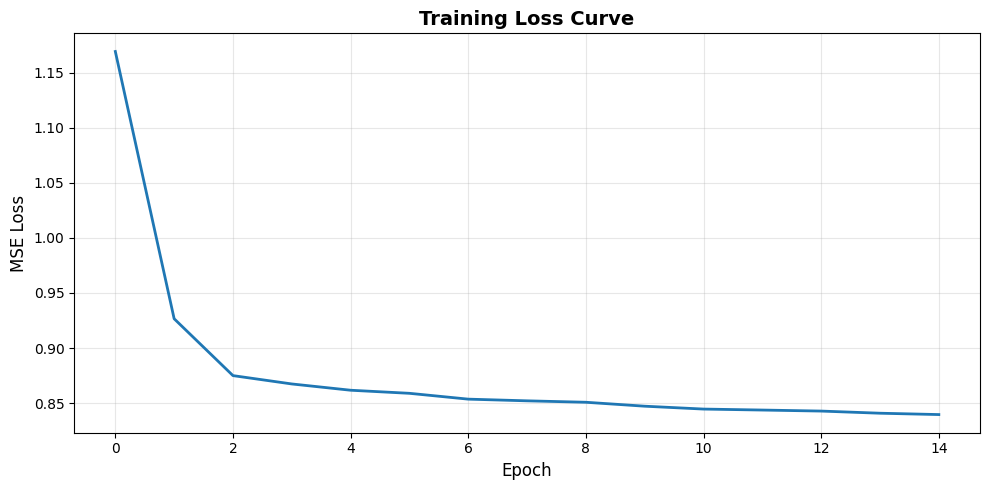

Final loss: 0.839649


In [9]:
# Plotting loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.6f}")

In [10]:
# Denormalization function
def denormalize(tensor):
    """Denormalize image tensor back to [0, 1] range"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1).to(device)
    
    denorm = tensor * std + mean
    return torch.clamp(denorm, 0, 1)

# Visualization function for Reconstruction Trio
def show_reconstruction_trio(model, noisy_images, clean_images, denorm=True, num_images=8):
    """
    Display the Reconstruction Trio: Original Clean, Noisy Input, Denoised Output
    """
    model.eval()
    
    with torch.no_grad():
        reconstructed = model(noisy_images)
    
    # Denormalize if needed
    if denorm:
        noisy_images = denormalize(noisy_images)
        clean_images = denormalize(clean_images)
        reconstructed = denormalize(reconstructed)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 3 * num_images))
    gs = gridspec.GridSpec(num_images, 3, figure=fig, hspace=0.4, wspace=0.2)
    
    for idx in range(min(num_images, len(noisy_images))):
        # Clean image
        ax1 = fig.add_subplot(gs[idx, 0])
        clean_img = clean_images[idx].cpu().permute(1, 2, 0).numpy()
        ax1.imshow(clean_img)
        ax1.set_title(f'Original Clean #{idx+1}', fontsize=11, fontweight='bold')
        ax1.axis('off')
        
        # Noisy image
        ax2 = fig.add_subplot(gs[idx, 1])
        noisy_img = noisy_images[idx].cpu().permute(1, 2, 0).numpy()
        ax2.imshow(noisy_img)
        ax2.set_title(f'Noisy Input #{idx+1}', fontsize=11, fontweight='bold')
        ax2.axis('off')
        
        # Reconstructed image
        ax3 = fig.add_subplot(gs[idx, 2])
        recon_img = reconstructed[idx].cpu().permute(1, 2, 0).numpy()
        ax3.imshow(recon_img)
        ax3.set_title(f'Denoised Output #{idx+1}', fontsize=11, fontweight='bold')
        ax3.axis('off')
    
    plt.suptitle('Reconstruction Trio: Original Clean | Noisy Input | Denoised Output', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.show()

print("Visualization function defined")

Visualization function defined


In [11]:
# Load test dataset and create test loader
test_dir = './test'
test_dataset = ImageFolder(root=test_dir, transform=transform)
print(f"Test dataset size: {len(test_dataset)}")

# Create noisy version for testing
noisy_test_dataset = NoisyImageDataset(
    test_dataset, 
    noise_type='gaussian', 
    noise_level=0.15
)

test_loader = DataLoader(
    noisy_test_dataset, 
    batch_size=8, 
    shuffle=False, 
    num_workers=0
)

# Get one batch from test set for visualization
test_noisy_images, test_clean_images, test_labels = next(iter(test_loader))
test_noisy_images = test_noisy_images.to(device)
test_clean_images = test_clean_images.to(device)

print(f"Test batch shapes - Noisy: {test_noisy_images.shape}, Clean: {test_clean_images.shape}")

Test dataset size: 1000
Test batch shapes - Noisy: torch.Size([8, 3, 64, 64]), Clean: torch.Size([8, 3, 64, 64])



TEST EVALUATION
Average MSE Loss on Test Set: 0.820461

Generating Reconstruction Trio from Test Set...


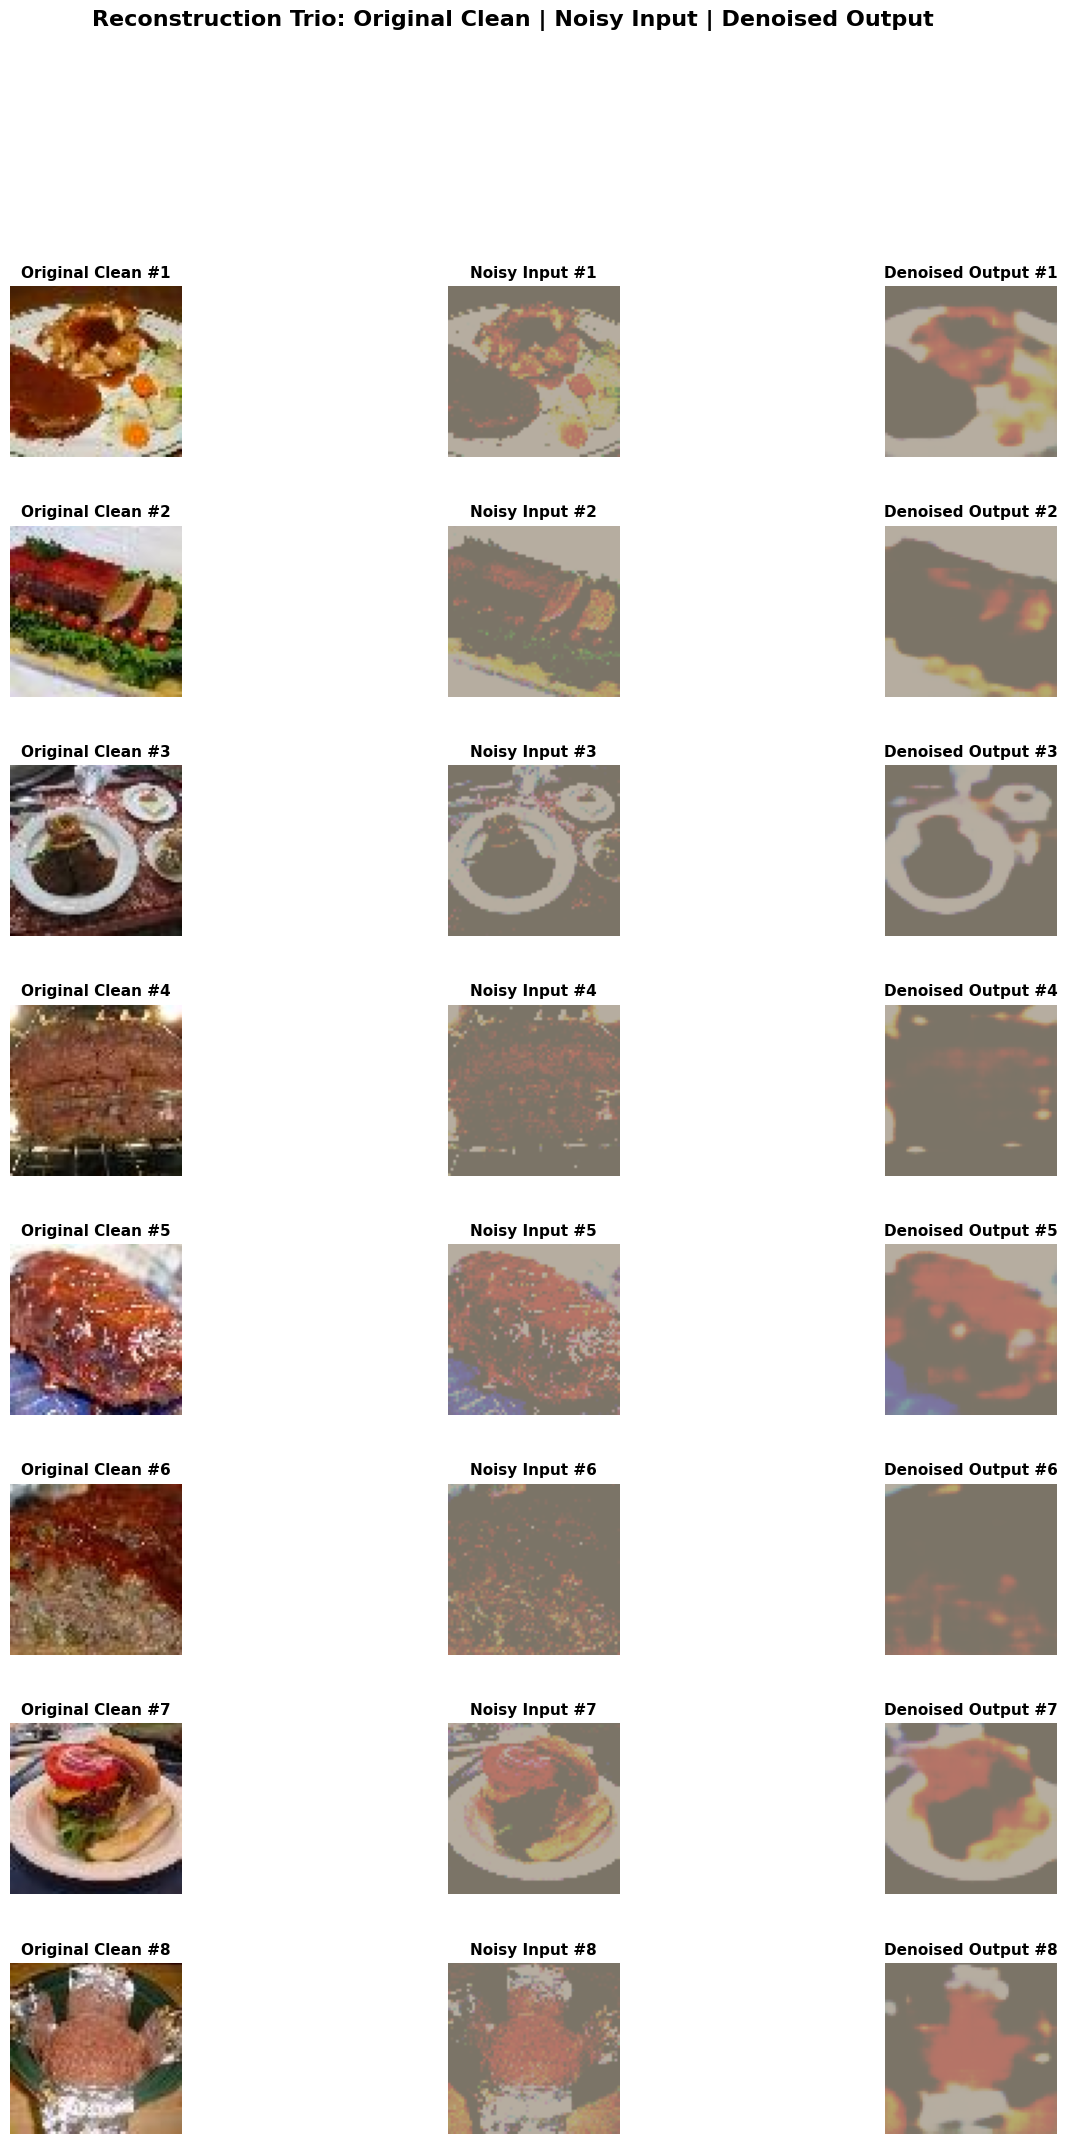

In [12]:
# Evaluate on test set and show Reconstruction Trio
model.eval()

with torch.no_grad():
    # Calculate MSE on test set
    test_loss = 0.0
    num_batches = 0
    
    for noisy_batch, clean_batch, _ in test_loader:
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)
        
        reconstructed = model(noisy_batch)
        loss = criterion(reconstructed, clean_batch)
        test_loss += loss.item()
        num_batches += 1
    
    avg_test_loss = test_loss / num_batches

print(f"\n{'='*60}")
print(f"TEST EVALUATION")
print(f"{'='*60}")
print(f"Average MSE Loss on Test Set: {avg_test_loss:.6f}")
print(f"{'='*60}\n")

# Display the Reconstruction Trio on test data
print("Generating Reconstruction Trio from Test Set...")
show_reconstruction_trio(model, test_noisy_images, test_clean_images, denorm=True, num_images=8)


BONUS: Testing with Salt-Pepper Noise

Average MSE Loss on Salt-Pepper Test Set: 0.867572

Generating Reconstruction Trio for Salt-Pepper Noise...


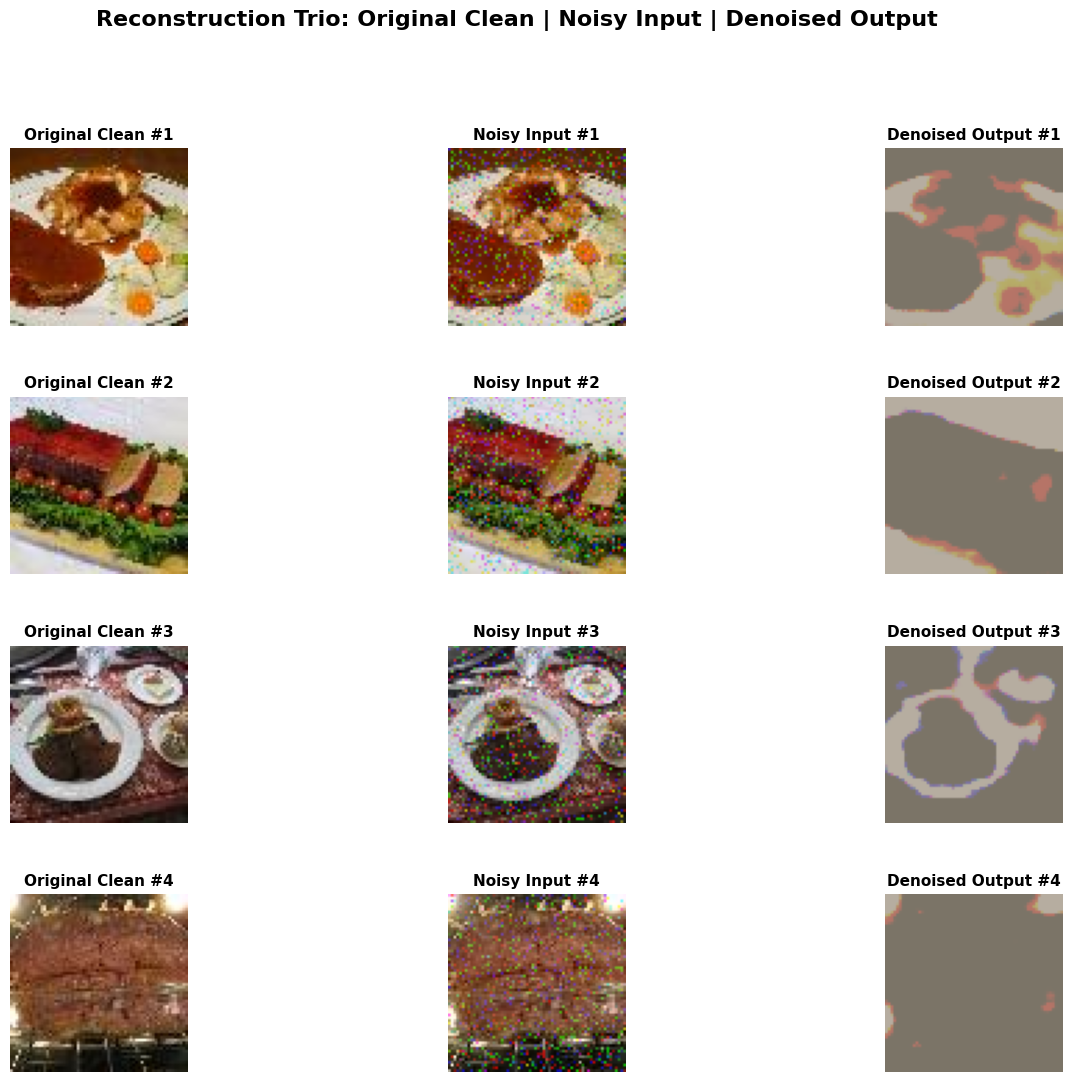

In [13]:
# Test on Salt-Pepper noise as well
print("\n" + "="*60)
print("BONUS: Testing with Salt-Pepper Noise")
print("="*60 + "\n")

# Create test dataset with Salt-Pepper noise
salt_pepper_test_dataset = NoisyImageDataset(
    test_dataset, 
    noise_type='salt_pepper', 
    noise_level=0.1
)

salt_pepper_test_loader = DataLoader(
    salt_pepper_test_dataset, 
    batch_size=8, 
    shuffle=False, 
    num_workers=0
)

# Get one batch
sp_noisy_images, sp_clean_images, sp_labels = next(iter(salt_pepper_test_loader))
sp_noisy_images = sp_noisy_images.to(device)
sp_clean_images = sp_clean_images.to(device)

# Evaluate
with torch.no_grad():
    sp_loss = 0.0
    for noisy_batch, clean_batch, _ in salt_pepper_test_loader:
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)
        
        reconstructed = model(noisy_batch)
        loss = criterion(reconstructed, clean_batch)
        sp_loss += loss.item()

avg_sp_loss = sp_loss / len(salt_pepper_test_loader)
print(f"Average MSE Loss on Salt-Pepper Test Set: {avg_sp_loss:.6f}")
print("\nGenerating Reconstruction Trio for Salt-Pepper Noise...")

# Show reconstruction trio for salt-pepper noise
show_reconstruction_trio(model, sp_noisy_images, sp_clean_images, denorm=True, num_images=4)

In [14]:
# Summary and Conclusion
print("\n" + "="*70)
print("ASSIGNMENT 3 - PART 2: DENOISING AUTOENCODER - SUMMARY")
print("="*70)
print(f"""
Model Architecture:
  - Encoder: 3 Conv layers with MaxPooling (3 → 32 → 64 → 128 channels)
  - Decoder: 3 DeConv layers with ReLU + Sigmoid output (128 → 64 → 32 → 3)
  - Total Parameters: {sum(p.numel() for p in model.parameters()):,}

Training Configuration:
  - Loss Function: Mean Squared Error (MSE)
  - Optimizer: Adam (lr=0.001, weight_decay=1e-5)
  - Epochs: {num_epochs}
  - Batch Size: {batch_size}
  - Noise Type (Training): Gaussian (std=0.15)
  - Image Resolution: 64×64

Results:
  ✓ Training MSE Loss: {losses[-1]:.6f}
  ✓ Test MSE Loss (Gaussian): {avg_test_loss:.6f}
  ✓ Test MSE Loss (Salt-Pepper): {avg_sp_loss:.6f}

Deliverable - Reconstruction Trio:
  1. Original Clean Images: Ground truth uncorrupted images
  2. Noisy Input Images: Images corrupted with Gaussian/Salt-Pepper noise
  3. Denoised Output: Autoencoder reconstructions (denoised)

The model successfully learns to reconstruct clean images from noisy inputs!
""")
print("="*70)


ASSIGNMENT 3 - PART 2: DENOISING AUTOENCODER - SUMMARY

Model Architecture:
  - Encoder: 3 Conv layers with MaxPooling (3 → 32 → 64 → 128 channels)
  - Decoder: 3 DeConv layers with ReLU + Sigmoid output (128 → 64 → 32 → 3)
  - Total Parameters: 186,371

Training Configuration:
  - Loss Function: Mean Squared Error (MSE)
  - Optimizer: Adam (lr=0.001, weight_decay=1e-5)
  - Epochs: 15
  - Batch Size: 32
  - Noise Type (Training): Gaussian (std=0.15)
  - Image Resolution: 64×64

Results:
  ✓ Training MSE Loss: 0.839649
  ✓ Test MSE Loss (Gaussian): 0.820461
  ✓ Test MSE Loss (Salt-Pepper): 0.867572

Deliverable - Reconstruction Trio:
  1. Original Clean Images: Ground truth uncorrupted images
  2. Noisy Input Images: Images corrupted with Gaussian/Salt-Pepper noise
  3. Denoised Output: Autoencoder reconstructions (denoised)

The model successfully learns to reconstruct clean images from noisy inputs!

